# Tuning hyperparameters

Load data:

In [1]:
import os
import sys

notebook_dir = os.getcwd()
shallow_dir = os.path.dirname(notebook_dir)
python_dir = os.path.dirname(shallow_dir)
modules_path = os.path.join(python_dir, 'Modules')

sys.path.append(modules_path)

In [2]:
from read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\Christine\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\Christine\Documents\Python\Speciale_Kode
Data_folder: c:\Users\Christine\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78900, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78900, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Import model and choose parameter search grid

In [3]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from xgboost import XGBRegressor

# Initialize model:
model_DK1_forecast = XGBRegressor(max_depth = 9, learning_rate = 0.01, subsample = 0.8, colsample_bytree = 1.0)
model_DK1_actuals = XGBRegressor(max_depth = 9, learning_rate = 0.1, subsample = 0.8, colsample_bytree = 1.0)
model_DK2_forecast = XGBRegressor(max_depth = 3, learning_rate = 0.01, subsample = 0.8, colsample_bytree = 0.8)
model_DK2_actuals = XGBRegressor(max_depth = 9, learning_rate = 0.1, subsample = 0.8, colsample_bytree = 1.0)

## Choose validation setup


**Setup 1**

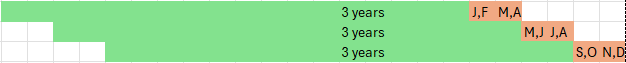

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [4]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Test set: 8760 hours → 52 full weeks + 24 remaining hours (excluded)

Week 1/52: 2025-01-01 00:00:00 → 2025-01-07 23:00:00 (training on 78900 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 368.562  MAE: 309.231  SMAPE: 75.337%

Week 2/52: 2025-01-08 00:00:00 → 2025-01-14 23:00:00 (training on 79068 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 331.078  MAE: 277.086  SMAPE: 46.466%

Week 3/52: 2025-01-15 00:00:00 → 2025-01-21 23:00:00 (training on 79236 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 841.961  MAE: 592.531  SMAPE: 60.468%

Week 4/52: 2025-01-22 00:00:00 → 2025-01-28 23:00:00 (training on 79404 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 353.832  MAE: 298.096  SMAPE: 52.157%

Week 5/52: 2025-01-29 00:00:00 → 2025-02-04 23:00:00 (training on 79572 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 361.585  MAE: 312.021  SMAPE: 37.814%

Week 6/52: 2025-02-05 00:00:00 → 2025-02-11 23:00:00 (training on 79740 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 245.994  MAE: 197.647  SMAPE: 26.478%

Week 7/52: 2025-02-12 00:00:00 → 2025-02-18 23:00:00 (training on 79908 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 494.808  MAE: 429.625  SMAPE: 46.964%

Week 8/52: 2025-02-19 00:00:00 → 2025-02-25 23:00:00 (training on 80076 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 321.377  MAE: 275.718  SMAPE: 45.146%

Week 9/52: 2025-02-26 00:00:00 → 2025-03-04 23:00:00 (training on 80244 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 290.089  MAE: 249.889  SMAPE: 43.055%

Week 10/52: 2025-03-05 00:00:00 → 2025-03-11 23:00:00 (training on 80412 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 344.546  MAE: 281.998  SMAPE: 56.614%

Week 11/52: 2025-03-12 00:00:00 → 2025-03-18 23:00:00 (training on 80580 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 275.601  MAE: 223.058  SMAPE: 36.798%

Week 12/52: 2025-03-19 00:00:00 → 2025-03-25 23:00:00 (training on 80748 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 380.033  MAE: 326.433  SMAPE: 72.687%

Week 13/52: 2025-03-26 00:00:00 → 2025-04-01 23:00:00 (training on 80916 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 235.276  MAE: 196.664  SMAPE: 51.078%

Week 14/52: 2025-04-02 00:00:00 → 2025-04-08 23:00:00 (training on 81084 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 277.510  MAE: 228.821  SMAPE: 63.254%

Week 15/52: 2025-04-09 00:00:00 → 2025-04-15 23:00:00 (training on 81252 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 291.705  MAE: 234.899  SMAPE: 72.873%

Week 16/52: 2025-04-16 00:00:00 → 2025-04-22 23:00:00 (training on 81420 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 237.936  MAE: 187.611  SMAPE: 45.521%

Week 17/52: 2025-04-23 00:00:00 → 2025-04-29 23:00:00 (training on 81588 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 221.901  MAE: 178.838  SMAPE: 52.460%

Week 18/52: 2025-04-30 00:00:00 → 2025-05-06 23:00:00 (training on 81756 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 236.758  MAE: 178.297  SMAPE: 61.983%

Week 19/52: 2025-05-07 00:00:00 → 2025-05-13 23:00:00 (training on 81924 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 232.517  MAE: 197.062  SMAPE: 57.415%

Week 20/52: 2025-05-14 00:00:00 → 2025-05-20 23:00:00 (training on 82092 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 234.683  MAE: 194.584  SMAPE: 67.755%

Week 21/52: 2025-05-21 00:00:00 → 2025-05-27 23:00:00 (training on 82260 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 299.962  MAE: 253.421  SMAPE: 99.207%

Week 22/52: 2025-05-28 00:00:00 → 2025-06-03 23:00:00 (training on 82428 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 239.427  MAE: 192.844  SMAPE: 70.973%

Week 23/52: 2025-06-04 00:00:00 → 2025-06-10 23:00:00 (training on 82596 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 207.439  MAE: 160.475  SMAPE: 64.793%

Week 24/52: 2025-06-11 00:00:00 → 2025-06-17 23:00:00 (training on 82764 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 237.437  MAE: 200.387  SMAPE: 77.296%

Week 25/52: 2025-06-18 00:00:00 → 2025-06-24 23:00:00 (training on 82932 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 293.214  MAE: 255.695  SMAPE: 95.323%

Week 26/52: 2025-06-25 00:00:00 → 2025-07-01 23:00:00 (training on 83100 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 447.158  MAE: 283.950  SMAPE: 72.944%

Week 27/52: 2025-07-02 00:00:00 → 2025-07-08 23:00:00 (training on 83268 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 251.188  MAE: 206.603  SMAPE: 63.997%

Week 28/52: 2025-07-09 00:00:00 → 2025-07-15 23:00:00 (training on 83436 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 173.804  MAE: 158.021  SMAPE: 37.964%

Week 29/52: 2025-07-16 00:00:00 → 2025-07-22 23:00:00 (training on 83604 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 163.690  MAE: 137.588  SMAPE: 33.891%

Week 30/52: 2025-07-23 00:00:00 → 2025-07-29 23:00:00 (training on 83772 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 188.930  MAE: 145.953  SMAPE: 34.746%

Week 31/52: 2025-07-30 00:00:00 → 2025-08-05 23:00:00 (training on 83940 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 289.694  MAE: 205.794  SMAPE: 69.136%

Week 32/52: 2025-08-06 00:00:00 → 2025-08-12 23:00:00 (training on 84108 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 306.951  MAE: 245.896  SMAPE: 76.384%

Week 33/52: 2025-08-13 00:00:00 → 2025-08-19 23:00:00 (training on 84276 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 252.272  MAE: 176.044  SMAPE: 42.777%

Week 34/52: 2025-08-20 00:00:00 → 2025-08-26 23:00:00 (training on 84444 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 198.431  MAE: 157.839  SMAPE: 42.868%

Week 35/52: 2025-08-27 00:00:00 → 2025-09-02 23:00:00 (training on 84612 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 284.244  MAE: 202.411  SMAPE: 39.275%

Week 36/52: 2025-09-03 00:00:00 → 2025-09-09 23:00:00 (training on 84780 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 385.695  MAE: 255.485  SMAPE: 54.323%

Week 37/52: 2025-09-10 00:00:00 → 2025-09-16 23:00:00 (training on 84948 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 462.423  MAE: 378.589  SMAPE: 106.669%

Week 38/52: 2025-09-17 00:00:00 → 2025-09-23 23:00:00 (training on 85116 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 327.563  MAE: 276.811  SMAPE: 95.255%

Week 39/52: 2025-09-24 00:00:00 → 2025-09-30 23:00:00 (training on 85284 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 376.551  MAE: 249.543  SMAPE: 44.492%

Week 40/52: 2025-10-01 00:00:00 → 2025-10-07 23:00:00 (training on 85452 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 410.466  MAE: 347.587  SMAPE: 94.846%

Week 41/52: 2025-10-08 00:00:00 → 2025-10-14 23:00:00 (training on 85620 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 383.279  MAE: 274.744  SMAPE: 40.419%

Week 42/52: 2025-10-15 00:00:00 → 2025-10-21 23:00:00 (training on 85788 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 300.127  MAE: 248.656  SMAPE: 38.826%

Week 43/52: 2025-10-22 00:00:00 → 2025-10-28 23:00:00 (training on 85956 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 290.583  MAE: 232.381  SMAPE: 72.075%

Week 44/52: 2025-10-29 00:00:00 → 2025-11-04 23:00:00 (training on 86124 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 180.198  MAE: 147.309  SMAPE: 33.208%

Week 45/52: 2025-11-05 00:00:00 → 2025-11-11 23:00:00 (training on 86292 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 279.294  MAE: 249.674  SMAPE: 39.842%

Week 46/52: 2025-11-12 00:00:00 → 2025-11-18 23:00:00 (training on 86460 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 213.309  MAE: 185.693  SMAPE: 33.960%

Week 47/52: 2025-11-19 00:00:00 → 2025-11-25 23:00:00 (training on 86628 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 560.941  MAE: 374.933  SMAPE: 41.695%

Week 48/52: 2025-11-26 00:00:00 → 2025-12-02 23:00:00 (training on 86796 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 340.345  MAE: 232.542  SMAPE: 33.544%

Week 49/52: 2025-12-03 00:00:00 → 2025-12-09 23:00:00 (training on 86964 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 293.709  MAE: 224.126  SMAPE: 31.340%

Week 50/52: 2025-12-10 00:00:00 → 2025-12-16 23:00:00 (training on 87132 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 229.923  MAE: 182.614  SMAPE: 34.497%

Week 51/52: 2025-12-17 00:00:00 → 2025-12-23 23:00:00 (training on 87300 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 176.131  MAE: 139.685  SMAPE: 27.460%

Week 52/52: 2025-12-24 00:00:00 → 2025-12-30 23:00:00 (training on 87468 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 110.414  MAE: 91.799  SMAPE: 15.692%

Final evaluation results (52 weeks)
  Average RMSE:  302.549
  Average MAE:   239.331
  Average SMAPE: 54.462%

Weekly results:
 week  val_start             val_end  train_size  weekly_rmse  weekly_mae  weekly_smape
    1 2025-01-01 2025-01-07 23:00:00       78900   368.562138  309.230582     75.336517
    2 2025-01-08 2025-01-14 23:00:00       79068   331.077922  277.085925     46.465577
    3 2025-01-15 2025-01-21 23:00:00       79236   841.960872  592.531192     60.467611
    4 2025-01-22 2025-01-28 23:00:00       79404   353.832403  298.096178     52.157244
    5 2025-01-29 2025-02-04 23:00:00       79572   361.584675  312.020867     37.813899
    6 2025-02-05 2025-02-11 23:00:00       79740   245.994388  197.647177     26.477898
    7 2025-02-12 2025-02-18 23:00:00       79908   494.807674  429.625423     46.964438
    8 2025-02-19 2025-02-25 23:00:00       80076   321.377141  275.717938     45.145606
    9 2025-02-26 2025-03-04 23:00:

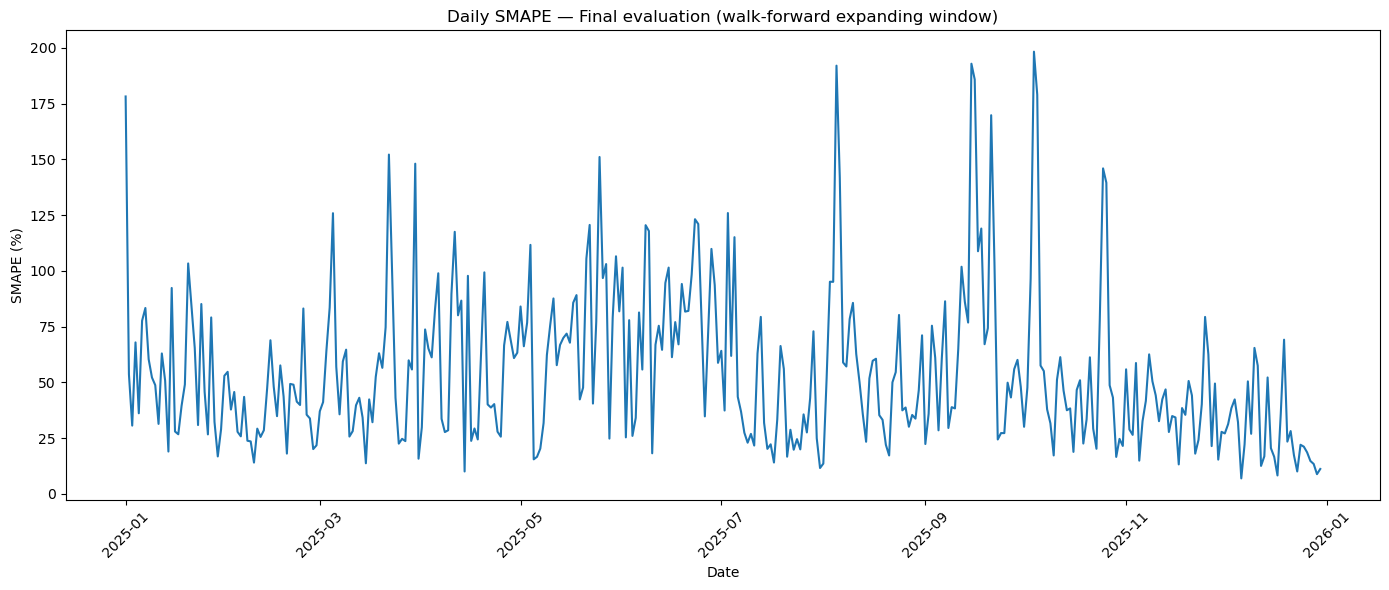

ValueError: If using all scalar values, you must pass an index

In [6]:
from Cross_Validation_runner_copy import run_final_evaluation
import itertools
import pandas as pd
import os

results = run_final_evaluation(
    model=model_DK1_forecast,  # your best model from hyperparameter search
    train_dataset=DK1_train,   # 9 years
    test_dataset=DK1_test,     # 1 year (from read_data.py, split at 2025-01-01)
    use_scaler=True,
    print_week_results=True,
    plot=True,
    one_step_ahead=False,      # set True to compare against oracle predictions
)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(python_dir, "Shallow learners")
folder = os.path.join(folder, "XGBoost")
base_filename = "DK1_final_evaluation_forecast_params.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_final_evaluation_forecast_params.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


Test set: 8760 hours → 52 full weeks + 24 remaining hours (excluded)

Week 1/52: 2025-01-01 00:00:00 → 2025-01-07 23:00:00 (training on 78900 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 495.494  MAE: 386.097  SMAPE: 83.674%

Week 2/52: 2025-01-08 00:00:00 → 2025-01-14 23:00:00 (training on 79068 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 400.849  MAE: 344.978  SMAPE: 67.404%

Week 3/52: 2025-01-15 00:00:00 → 2025-01-21 23:00:00 (training on 79236 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 836.190  MAE: 573.604  SMAPE: 60.038%

Week 4/52: 2025-01-22 00:00:00 → 2025-01-28 23:00:00 (training on 79404 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 376.524  MAE: 309.964  SMAPE: 53.678%

Week 5/52: 2025-01-29 00:00:00 → 2025-02-04 23:00:00 (training on 79572 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 327.203  MAE: 276.959  SMAPE: 32.323%

Week 6/52: 2025-02-05 00:00:00 → 2025-02-11 23:00:00 (training on 79740 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 363.821  MAE: 271.646  SMAPE: 32.387%

Week 7/52: 2025-02-12 00:00:00 → 2025-02-18 23:00:00 (training on 79908 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 398.874  MAE: 321.899  SMAPE: 33.421%

Week 8/52: 2025-02-19 00:00:00 → 2025-02-25 23:00:00 (training on 80076 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 435.714  MAE: 381.805  SMAPE: 55.311%

Week 9/52: 2025-02-26 00:00:00 → 2025-03-04 23:00:00 (training on 80244 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 289.624  MAE: 228.341  SMAPE: 39.917%

Week 10/52: 2025-03-05 00:00:00 → 2025-03-11 23:00:00 (training on 80412 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 369.141  MAE: 277.422  SMAPE: 54.059%

Week 11/52: 2025-03-12 00:00:00 → 2025-03-18 23:00:00 (training on 80580 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 222.638  MAE: 172.390  SMAPE: 30.224%

Week 12/52: 2025-03-19 00:00:00 → 2025-03-25 23:00:00 (training on 80748 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 370.161  MAE: 294.150  SMAPE: 67.927%

Week 13/52: 2025-03-26 00:00:00 → 2025-04-01 23:00:00 (training on 80916 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 219.602  MAE: 178.387  SMAPE: 51.144%

Week 14/52: 2025-04-02 00:00:00 → 2025-04-08 23:00:00 (training on 81084 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 253.409  MAE: 200.129  SMAPE: 60.979%

Week 15/52: 2025-04-09 00:00:00 → 2025-04-15 23:00:00 (training on 81252 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 320.163  MAE: 229.303  SMAPE: 68.321%

Week 16/52: 2025-04-16 00:00:00 → 2025-04-22 23:00:00 (training on 81420 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 243.931  MAE: 178.011  SMAPE: 51.507%

Week 17/52: 2025-04-23 00:00:00 → 2025-04-29 23:00:00 (training on 81588 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 189.713  MAE: 132.019  SMAPE: 44.310%

Week 18/52: 2025-04-30 00:00:00 → 2025-05-06 23:00:00 (training on 81756 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 219.231  MAE: 152.913  SMAPE: 59.767%

Week 19/52: 2025-05-07 00:00:00 → 2025-05-13 23:00:00 (training on 81924 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 167.212  MAE: 130.400  SMAPE: 48.574%

Week 20/52: 2025-05-14 00:00:00 → 2025-05-20 23:00:00 (training on 82092 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 181.340  MAE: 130.565  SMAPE: 56.204%

Week 21/52: 2025-05-21 00:00:00 → 2025-05-27 23:00:00 (training on 82260 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 313.212  MAE: 238.871  SMAPE: 102.058%

Week 22/52: 2025-05-28 00:00:00 → 2025-06-03 23:00:00 (training on 82428 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 218.199  MAE: 155.336  SMAPE: 62.686%

Week 23/52: 2025-06-04 00:00:00 → 2025-06-10 23:00:00 (training on 82596 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 201.632  MAE: 145.704  SMAPE: 74.880%

Week 24/52: 2025-06-11 00:00:00 → 2025-06-17 23:00:00 (training on 82764 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 214.795  MAE: 160.725  SMAPE: 73.099%

Week 25/52: 2025-06-18 00:00:00 → 2025-06-24 23:00:00 (training on 82932 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 261.454  MAE: 196.333  SMAPE: 78.924%

Week 26/52: 2025-06-25 00:00:00 → 2025-07-01 23:00:00 (training on 83100 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 430.234  MAE: 271.711  SMAPE: 81.204%

Week 27/52: 2025-07-02 00:00:00 → 2025-07-08 23:00:00 (training on 83268 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 266.215  MAE: 211.059  SMAPE: 78.021%

Week 28/52: 2025-07-09 00:00:00 → 2025-07-15 23:00:00 (training on 83436 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 188.522  MAE: 157.132  SMAPE: 50.523%

Week 29/52: 2025-07-16 00:00:00 → 2025-07-22 23:00:00 (training on 83604 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 185.046  MAE: 134.584  SMAPE: 35.709%

Week 30/52: 2025-07-23 00:00:00 → 2025-07-29 23:00:00 (training on 83772 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 199.069  MAE: 143.687  SMAPE: 40.521%

Week 31/52: 2025-07-30 00:00:00 → 2025-08-05 23:00:00 (training on 83940 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 285.905  MAE: 195.207  SMAPE: 69.235%

Week 32/52: 2025-08-06 00:00:00 → 2025-08-12 23:00:00 (training on 84108 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 271.211  MAE: 202.322  SMAPE: 74.875%

Week 33/52: 2025-08-13 00:00:00 → 2025-08-19 23:00:00 (training on 84276 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 219.436  MAE: 148.421  SMAPE: 44.497%

Week 34/52: 2025-08-20 00:00:00 → 2025-08-26 23:00:00 (training on 84444 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 182.928  MAE: 133.887  SMAPE: 42.881%

Week 35/52: 2025-08-27 00:00:00 → 2025-09-02 23:00:00 (training on 84612 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 253.381  MAE: 174.918  SMAPE: 44.844%

Week 36/52: 2025-09-03 00:00:00 → 2025-09-09 23:00:00 (training on 84780 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 328.447  MAE: 220.464  SMAPE: 52.164%

Week 37/52: 2025-09-10 00:00:00 → 2025-09-16 23:00:00 (training on 84948 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 514.761  MAE: 402.841  SMAPE: 110.433%

Week 38/52: 2025-09-17 00:00:00 → 2025-09-23 23:00:00 (training on 85116 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 323.902  MAE: 259.219  SMAPE: 89.203%

Week 39/52: 2025-09-24 00:00:00 → 2025-09-30 23:00:00 (training on 85284 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 386.777  MAE: 283.685  SMAPE: 63.309%

Week 40/52: 2025-10-01 00:00:00 → 2025-10-07 23:00:00 (training on 85452 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 379.965  MAE: 305.420  SMAPE: 95.337%

Week 41/52: 2025-10-08 00:00:00 → 2025-10-14 23:00:00 (training on 85620 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 362.721  MAE: 297.232  SMAPE: 59.237%

Week 42/52: 2025-10-15 00:00:00 → 2025-10-21 23:00:00 (training on 85788 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 404.559  MAE: 326.789  SMAPE: 54.186%

Week 43/52: 2025-10-22 00:00:00 → 2025-10-28 23:00:00 (training on 85956 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 275.319  MAE: 222.869  SMAPE: 71.268%

Week 44/52: 2025-10-29 00:00:00 → 2025-11-04 23:00:00 (training on 86124 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 235.813  MAE: 196.282  SMAPE: 41.239%

Week 45/52: 2025-11-05 00:00:00 → 2025-11-11 23:00:00 (training on 86292 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 327.452  MAE: 296.294  SMAPE: 51.069%

Week 46/52: 2025-11-12 00:00:00 → 2025-11-18 23:00:00 (training on 86460 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 249.415  MAE: 215.078  SMAPE: 41.823%

Week 47/52: 2025-11-19 00:00:00 → 2025-11-25 23:00:00 (training on 86628 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 534.194  MAE: 370.056  SMAPE: 42.270%

Week 48/52: 2025-11-26 00:00:00 → 2025-12-02 23:00:00 (training on 86796 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 390.934  MAE: 298.141  SMAPE: 40.850%

Week 49/52: 2025-12-03 00:00:00 → 2025-12-09 23:00:00 (training on 86964 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 287.019  MAE: 225.227  SMAPE: 31.075%

Week 50/52: 2025-12-10 00:00:00 → 2025-12-16 23:00:00 (training on 87132 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 302.365  MAE: 222.487  SMAPE: 37.498%

Week 51/52: 2025-12-17 00:00:00 → 2025-12-23 23:00:00 (training on 87300 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 218.972  MAE: 183.870  SMAPE: 33.602%

Week 52/52: 2025-12-24 00:00:00 → 2025-12-30 23:00:00 (training on 87468 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 157.915  MAE: 119.905  SMAPE: 19.970%

Final evaluation results (52 weeks)
  Average RMSE:  308.704
  Average MAE:   236.283
  Average SMAPE: 56.532%

Weekly results:
 week  val_start             val_end  train_size  weekly_rmse  weekly_mae  weekly_smape
    1 2025-01-01 2025-01-07 23:00:00       78900   495.494026  386.097164     83.673678
    2 2025-01-08 2025-01-14 23:00:00       79068   400.848532  344.978188     67.403804
    3 2025-01-15 2025-01-21 23:00:00       79236   836.190187  573.604275     60.037776
    4 2025-01-22 2025-01-28 23:00:00       79404   376.524005  309.963864     53.677799
    5 2025-01-29 2025-02-04 23:00:00       79572   327.202744  276.959067     32.322748
    6 2025-02-05 2025-02-11 23:00:00       79740   363.821365  271.645959     32.387365
    7 2025-02-12 2025-02-18 23:00:00       79908   398.874355  321.899065     33.421175
    8 2025-02-19 2025-02-25 23:00:00       80076   435.714019  381.805344     55.310574
    9 2025-02-26 2025-03-04 23:00

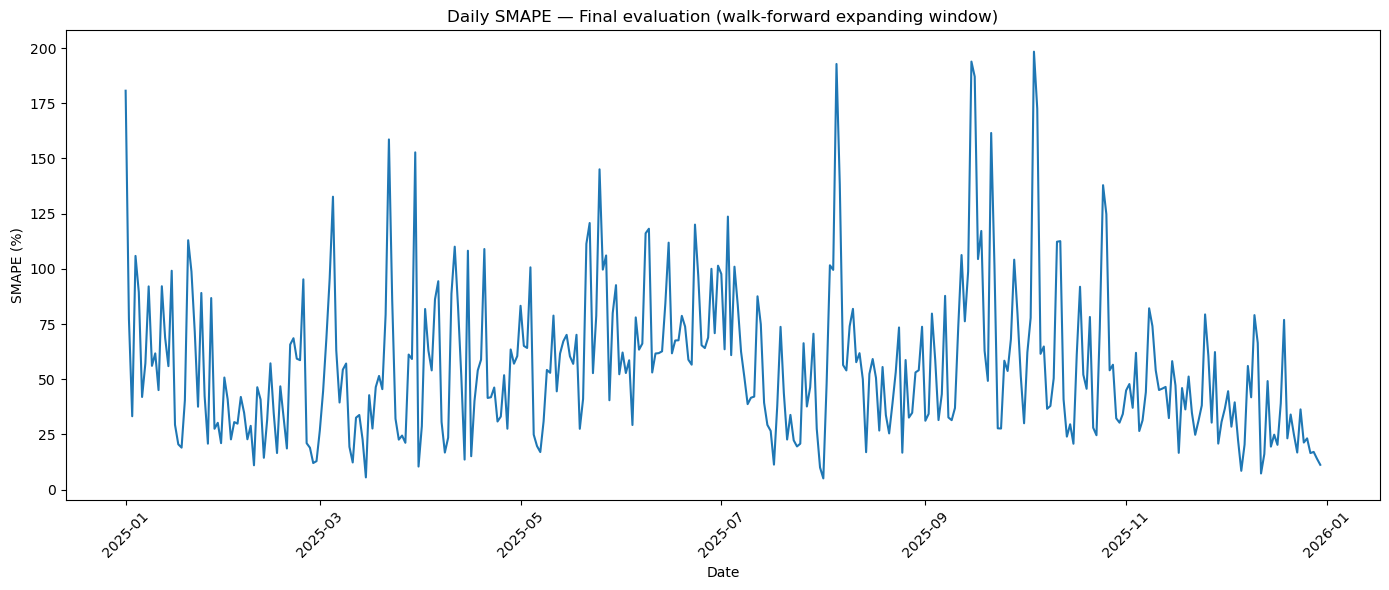

ValueError: If using all scalar values, you must pass an index

In [7]:
from Cross_Validation_runner_copy import run_final_evaluation
import itertools
import pandas as pd
import os

results = run_final_evaluation(
    model=model_DK1_actuals,  # your best model from hyperparameter search
    train_dataset=DK1_train,   # 9 years
    test_dataset=DK1_test,     # 1 year (from read_data.py, split at 2025-01-01)
    use_scaler=True,
    print_week_results=True,
    plot=True,
    one_step_ahead=False,      # set True to compare against oracle predictions
)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(python_dir, "Shallow learners")
folder = os.path.join(folder, "XGBoost")
base_filename = "DK1_final_evaluation_actuals_params.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_final_evaluation_actuals_params.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

Test set: 8760 hours → 52 full weeks + 24 remaining hours (excluded)

Week 1/52: 2025-01-01 00:00:00 → 2025-01-07 23:00:00 (training on 78900 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 337.879  MAE: 282.273  SMAPE: 74.768%

Week 2/52: 2025-01-08 00:00:00 → 2025-01-14 23:00:00 (training on 79068 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 380.762  MAE: 315.456  SMAPE: 57.776%

Week 3/52: 2025-01-15 00:00:00 → 2025-01-21 23:00:00 (training on 79236 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 938.795  MAE: 723.362  SMAPE: 77.159%

Week 4/52: 2025-01-22 00:00:00 → 2025-01-28 23:00:00 (training on 79404 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 349.763  MAE: 281.368  SMAPE: 46.085%

Week 5/52: 2025-01-29 00:00:00 → 2025-02-04 23:00:00 (training on 79572 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 466.437  MAE: 422.329  SMAPE: 52.293%

Week 6/52: 2025-02-05 00:00:00 → 2025-02-11 23:00:00 (training on 79740 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 320.471  MAE: 256.799  SMAPE: 34.623%

Week 7/52: 2025-02-12 00:00:00 → 2025-02-18 23:00:00 (training on 79908 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 567.667  MAE: 509.470  SMAPE: 57.751%

Week 8/52: 2025-02-19 00:00:00 → 2025-02-25 23:00:00 (training on 80076 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 282.868  MAE: 229.200  SMAPE: 38.351%

Week 9/52: 2025-02-26 00:00:00 → 2025-03-04 23:00:00 (training on 80244 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 351.319  MAE: 324.907  SMAPE: 58.780%

Week 10/52: 2025-03-05 00:00:00 → 2025-03-11 23:00:00 (training on 80412 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 382.238  MAE: 339.086  SMAPE: 66.764%

Week 11/52: 2025-03-12 00:00:00 → 2025-03-18 23:00:00 (training on 80580 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 355.054  MAE: 309.904  SMAPE: 51.750%

Week 12/52: 2025-03-19 00:00:00 → 2025-03-25 23:00:00 (training on 80748 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 428.257  MAE: 375.331  SMAPE: 84.932%

Week 13/52: 2025-03-26 00:00:00 → 2025-04-01 23:00:00 (training on 80916 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 291.122  MAE: 244.272  SMAPE: 53.586%

Week 14/52: 2025-04-02 00:00:00 → 2025-04-08 23:00:00 (training on 81084 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 318.991  MAE: 273.390  SMAPE: 67.776%

Week 15/52: 2025-04-09 00:00:00 → 2025-04-15 23:00:00 (training on 81252 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 292.362  MAE: 250.231  SMAPE: 68.368%

Week 16/52: 2025-04-16 00:00:00 → 2025-04-22 23:00:00 (training on 81420 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 290.138  MAE: 239.772  SMAPE: 49.591%

Week 17/52: 2025-04-23 00:00:00 → 2025-04-29 23:00:00 (training on 81588 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 287.914  MAE: 247.282  SMAPE: 61.264%

Week 18/52: 2025-04-30 00:00:00 → 2025-05-06 23:00:00 (training on 81756 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 277.012  MAE: 226.370  SMAPE: 67.413%

Week 19/52: 2025-05-07 00:00:00 → 2025-05-13 23:00:00 (training on 81924 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 282.487  MAE: 237.785  SMAPE: 50.562%

Week 20/52: 2025-05-14 00:00:00 → 2025-05-20 23:00:00 (training on 82092 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 303.723  MAE: 257.064  SMAPE: 76.832%

Week 21/52: 2025-05-21 00:00:00 → 2025-05-27 23:00:00 (training on 82260 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 276.830  MAE: 239.326  SMAPE: 82.583%

Week 22/52: 2025-05-28 00:00:00 → 2025-06-03 23:00:00 (training on 82428 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 296.290  MAE: 246.373  SMAPE: 77.116%

Week 23/52: 2025-06-04 00:00:00 → 2025-06-10 23:00:00 (training on 82596 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 267.148  MAE: 216.651  SMAPE: 72.395%

Week 24/52: 2025-06-11 00:00:00 → 2025-06-17 23:00:00 (training on 82764 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 284.937  MAE: 234.887  SMAPE: 77.696%

Week 25/52: 2025-06-18 00:00:00 → 2025-06-24 23:00:00 (training on 82932 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 344.767  MAE: 307.180  SMAPE: 100.346%

Week 26/52: 2025-06-25 00:00:00 → 2025-07-01 23:00:00 (training on 83100 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 497.040  MAE: 328.614  SMAPE: 77.317%

Week 27/52: 2025-07-02 00:00:00 → 2025-07-08 23:00:00 (training on 83268 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 289.114  MAE: 243.573  SMAPE: 60.712%

Week 28/52: 2025-07-09 00:00:00 → 2025-07-15 23:00:00 (training on 83436 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 259.123  MAE: 231.437  SMAPE: 51.334%

Week 29/52: 2025-07-16 00:00:00 → 2025-07-22 23:00:00 (training on 83604 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 258.138  MAE: 234.755  SMAPE: 49.118%

Week 30/52: 2025-07-23 00:00:00 → 2025-07-29 23:00:00 (training on 83772 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 251.824  MAE: 224.027  SMAPE: 48.276%

Week 31/52: 2025-07-30 00:00:00 → 2025-08-05 23:00:00 (training on 83940 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 276.339  MAE: 233.961  SMAPE: 74.216%

Week 32/52: 2025-08-06 00:00:00 → 2025-08-12 23:00:00 (training on 84108 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 327.373  MAE: 289.286  SMAPE: 82.353%

Week 33/52: 2025-08-13 00:00:00 → 2025-08-19 23:00:00 (training on 84276 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 318.177  MAE: 250.959  SMAPE: 54.825%

Week 34/52: 2025-08-20 00:00:00 → 2025-08-26 23:00:00 (training on 84444 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 260.175  MAE: 215.587  SMAPE: 48.938%

Week 35/52: 2025-08-27 00:00:00 → 2025-09-02 23:00:00 (training on 84612 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 340.235  MAE: 251.711  SMAPE: 41.540%

Week 36/52: 2025-09-03 00:00:00 → 2025-09-09 23:00:00 (training on 84780 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 440.510  MAE: 284.810  SMAPE: 51.276%

Week 37/52: 2025-09-10 00:00:00 → 2025-09-16 23:00:00 (training on 84948 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 389.714  MAE: 322.909  SMAPE: 85.039%

Week 38/52: 2025-09-17 00:00:00 → 2025-09-23 23:00:00 (training on 85116 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 338.791  MAE: 232.806  SMAPE: 59.450%

Week 39/52: 2025-09-24 00:00:00 → 2025-09-30 23:00:00 (training on 85284 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 415.233  MAE: 277.384  SMAPE: 40.634%

Week 40/52: 2025-10-01 00:00:00 → 2025-10-07 23:00:00 (training on 85452 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 426.160  MAE: 349.011  SMAPE: 88.278%

Week 41/52: 2025-10-08 00:00:00 → 2025-10-14 23:00:00 (training on 85620 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 447.884  MAE: 303.553  SMAPE: 40.338%

Week 42/52: 2025-10-15 00:00:00 → 2025-10-21 23:00:00 (training on 85788 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 316.977  MAE: 246.422  SMAPE: 38.735%

Week 43/52: 2025-10-22 00:00:00 → 2025-10-28 23:00:00 (training on 85956 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 301.036  MAE: 227.030  SMAPE: 72.135%

Week 44/52: 2025-10-29 00:00:00 → 2025-11-04 23:00:00 (training on 86124 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 195.004  MAE: 154.444  SMAPE: 33.469%

Week 45/52: 2025-11-05 00:00:00 → 2025-11-11 23:00:00 (training on 86292 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 306.123  MAE: 271.784  SMAPE: 42.245%

Week 46/52: 2025-11-12 00:00:00 → 2025-11-18 23:00:00 (training on 86460 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 260.016  MAE: 223.494  SMAPE: 43.628%

Week 47/52: 2025-11-19 00:00:00 → 2025-11-25 23:00:00 (training on 86628 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 665.470  MAE: 453.424  SMAPE: 51.644%

Week 48/52: 2025-11-26 00:00:00 → 2025-12-02 23:00:00 (training on 86796 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 366.332  MAE: 249.781  SMAPE: 44.679%

Week 49/52: 2025-12-03 00:00:00 → 2025-12-09 23:00:00 (training on 86964 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 382.756  MAE: 265.971  SMAPE: 35.660%

Week 50/52: 2025-12-10 00:00:00 → 2025-12-16 23:00:00 (training on 87132 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 214.100  MAE: 186.612  SMAPE: 36.042%

Week 51/52: 2025-12-17 00:00:00 → 2025-12-23 23:00:00 (training on 87300 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 188.603  MAE: 150.739  SMAPE: 29.023%

Week 52/52: 2025-12-24 00:00:00 → 2025-12-30 23:00:00 (training on 87468 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 159.071  MAE: 132.856  SMAPE: 27.756%

Final evaluation results (52 weeks)
  Average RMSE:  343.587
  Average MAE:   277.443
  Average SMAPE: 57.985%

Weekly results:
 week  val_start             val_end  train_size  weekly_rmse  weekly_mae  weekly_smape
    1 2025-01-01 2025-01-07 23:00:00       78900   337.878748  282.272903     74.767773
    2 2025-01-08 2025-01-14 23:00:00       79068   380.761947  315.456496     57.775545
    3 2025-01-15 2025-01-21 23:00:00       79236   938.794625  723.362373     77.159016
    4 2025-01-22 2025-01-28 23:00:00       79404   349.763423  281.367701     46.084925
    5 2025-01-29 2025-02-04 23:00:00       79572   466.437069  422.329165     52.293257
    6 2025-02-05 2025-02-11 23:00:00       79740   320.471399  256.799178     34.622525
    7 2025-02-12 2025-02-18 23:00:00       79908   567.666776  509.470180     57.751033
    8 2025-02-19 2025-02-25 23:00:00       80076   282.867671  229.199683     38.351341
    9 2025-02-26 2025-03-04 23:00

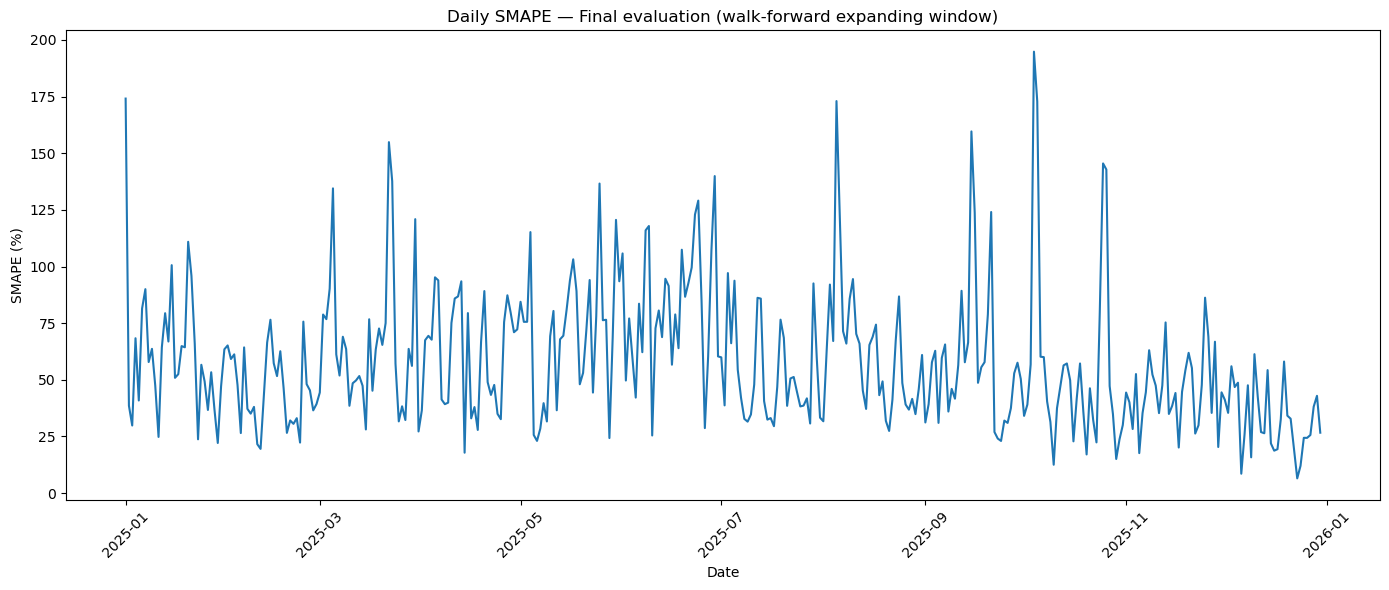

ValueError: If using all scalar values, you must pass an index

In [8]:
from Cross_Validation_runner_copy import run_final_evaluation
import itertools
import pandas as pd
import os

results = run_final_evaluation(
    model=model_DK2_forecast,  # your best model from hyperparameter search
    train_dataset=DK2_train,   # 9 years
    test_dataset=DK2_test,     # 1 year (from read_data.py, split at 2025-01-01)
    use_scaler=True,
    print_week_results=True,
    plot=True,
    one_step_ahead=False,      # set True to compare against oracle predictions
)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(python_dir, "Shallow learners")
folder = os.path.join(folder, "XGBoost")
base_filename = "DK2_final_evaluation_forecast_params.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_final_evaluation_forecast_params.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


Test set: 8760 hours → 52 full weeks + 24 remaining hours (excluded)

Week 1/52: 2025-01-01 00:00:00 → 2025-01-07 23:00:00 (training on 78900 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 510.601  MAE: 387.771  SMAPE: 78.719%

Week 2/52: 2025-01-08 00:00:00 → 2025-01-14 23:00:00 (training on 79068 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 416.226  MAE: 336.367  SMAPE: 65.585%

Week 3/52: 2025-01-15 00:00:00 → 2025-01-21 23:00:00 (training on 79236 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 949.247  MAE: 714.329  SMAPE: 78.880%

Week 4/52: 2025-01-22 00:00:00 → 2025-01-28 23:00:00 (training on 79404 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 384.712  MAE: 318.732  SMAPE: 49.421%

Week 5/52: 2025-01-29 00:00:00 → 2025-02-04 23:00:00 (training on 79572 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 289.616  MAE: 221.432  SMAPE: 22.946%

Week 6/52: 2025-02-05 00:00:00 → 2025-02-11 23:00:00 (training on 79740 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 522.356  MAE: 398.513  SMAPE: 41.696%

Week 7/52: 2025-02-12 00:00:00 → 2025-02-18 23:00:00 (training on 79908 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 275.861  MAE: 200.013  SMAPE: 18.797%

Week 8/52: 2025-02-19 00:00:00 → 2025-02-25 23:00:00 (training on 80076 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 621.574  MAE: 552.394  SMAPE: 67.007%

Week 9/52: 2025-02-26 00:00:00 → 2025-03-04 23:00:00 (training on 80244 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 446.159  MAE: 350.802  SMAPE: 55.160%

Week 10/52: 2025-03-05 00:00:00 → 2025-03-11 23:00:00 (training on 80412 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 438.277  MAE: 327.966  SMAPE: 59.051%

Week 11/52: 2025-03-12 00:00:00 → 2025-03-18 23:00:00 (training on 80580 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 251.563  MAE: 185.246  SMAPE: 32.677%

Week 12/52: 2025-03-19 00:00:00 → 2025-03-25 23:00:00 (training on 80748 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 440.998  MAE: 353.364  SMAPE: 78.373%

Week 13/52: 2025-03-26 00:00:00 → 2025-04-01 23:00:00 (training on 80916 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 329.413  MAE: 268.165  SMAPE: 55.894%

Week 14/52: 2025-04-02 00:00:00 → 2025-04-08 23:00:00 (training on 81084 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 430.111  MAE: 339.736  SMAPE: 74.299%

Week 15/52: 2025-04-09 00:00:00 → 2025-04-15 23:00:00 (training on 81252 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 406.554  MAE: 339.402  SMAPE: 78.034%

Week 16/52: 2025-04-16 00:00:00 → 2025-04-22 23:00:00 (training on 81420 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 278.314  MAE: 215.102  SMAPE: 43.738%

Week 17/52: 2025-04-23 00:00:00 → 2025-04-29 23:00:00 (training on 81588 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 268.905  MAE: 192.650  SMAPE: 49.361%

Week 18/52: 2025-04-30 00:00:00 → 2025-05-06 23:00:00 (training on 81756 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 305.092  MAE: 225.703  SMAPE: 67.192%

Week 19/52: 2025-05-07 00:00:00 → 2025-05-13 23:00:00 (training on 81924 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 254.320  MAE: 193.257  SMAPE: 40.882%

Week 20/52: 2025-05-14 00:00:00 → 2025-05-20 23:00:00 (training on 82092 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 338.819  MAE: 274.793  SMAPE: 76.052%

Week 21/52: 2025-05-21 00:00:00 → 2025-05-27 23:00:00 (training on 82260 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 299.401  MAE: 251.941  SMAPE: 85.502%

Week 22/52: 2025-05-28 00:00:00 → 2025-06-03 23:00:00 (training on 82428 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 265.210  MAE: 210.155  SMAPE: 72.750%

Week 23/52: 2025-06-04 00:00:00 → 2025-06-10 23:00:00 (training on 82596 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 255.998  MAE: 209.050  SMAPE: 76.245%

Week 24/52: 2025-06-11 00:00:00 → 2025-06-17 23:00:00 (training on 82764 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 249.668  MAE: 204.045  SMAPE: 79.149%

Week 25/52: 2025-06-18 00:00:00 → 2025-06-24 23:00:00 (training on 82932 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 340.507  MAE: 275.509  SMAPE: 98.739%

Week 26/52: 2025-06-25 00:00:00 → 2025-07-01 23:00:00 (training on 83100 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 508.306  MAE: 323.103  SMAPE: 79.254%

Week 27/52: 2025-07-02 00:00:00 → 2025-07-08 23:00:00 (training on 83268 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 296.600  MAE: 242.266  SMAPE: 64.246%

Week 28/52: 2025-07-09 00:00:00 → 2025-07-15 23:00:00 (training on 83436 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 247.005  MAE: 213.511  SMAPE: 50.864%

Week 29/52: 2025-07-16 00:00:00 → 2025-07-22 23:00:00 (training on 83604 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 314.250  MAE: 270.150  SMAPE: 60.765%

Week 30/52: 2025-07-23 00:00:00 → 2025-07-29 23:00:00 (training on 83772 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 309.932  MAE: 263.921  SMAPE: 58.315%

Week 31/52: 2025-07-30 00:00:00 → 2025-08-05 23:00:00 (training on 83940 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 270.572  MAE: 213.698  SMAPE: 72.726%

Week 32/52: 2025-08-06 00:00:00 → 2025-08-12 23:00:00 (training on 84108 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 340.921  MAE: 276.996  SMAPE: 80.543%

Week 33/52: 2025-08-13 00:00:00 → 2025-08-19 23:00:00 (training on 84276 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 313.089  MAE: 238.474  SMAPE: 54.706%

Week 34/52: 2025-08-20 00:00:00 → 2025-08-26 23:00:00 (training on 84444 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 247.804  MAE: 195.335  SMAPE: 46.221%

Week 35/52: 2025-08-27 00:00:00 → 2025-09-02 23:00:00 (training on 84612 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 276.812  MAE: 214.375  SMAPE: 34.728%

Week 36/52: 2025-09-03 00:00:00 → 2025-09-09 23:00:00 (training on 84780 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 384.716  MAE: 270.510  SMAPE: 46.347%

Week 37/52: 2025-09-10 00:00:00 → 2025-09-16 23:00:00 (training on 84948 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 581.831  MAE: 455.835  SMAPE: 90.866%

Week 38/52: 2025-09-17 00:00:00 → 2025-09-23 23:00:00 (training on 85116 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 494.008  MAE: 388.822  SMAPE: 71.559%

Week 39/52: 2025-09-24 00:00:00 → 2025-09-30 23:00:00 (training on 85284 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 349.823  MAE: 242.178  SMAPE: 32.461%

Week 40/52: 2025-10-01 00:00:00 → 2025-10-07 23:00:00 (training on 85452 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 400.935  MAE: 331.469  SMAPE: 81.235%

Week 41/52: 2025-10-08 00:00:00 → 2025-10-14 23:00:00 (training on 85620 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 382.121  MAE: 295.870  SMAPE: 38.609%

Week 42/52: 2025-10-15 00:00:00 → 2025-10-21 23:00:00 (training on 85788 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 554.620  MAE: 404.622  SMAPE: 48.474%

Week 43/52: 2025-10-22 00:00:00 → 2025-10-28 23:00:00 (training on 85956 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 455.150  MAE: 410.014  SMAPE: 90.335%

Week 44/52: 2025-10-29 00:00:00 → 2025-11-04 23:00:00 (training on 86124 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 407.246  MAE: 335.759  SMAPE: 52.604%

Week 45/52: 2025-11-05 00:00:00 → 2025-11-11 23:00:00 (training on 86292 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 446.543  MAE: 391.171  SMAPE: 41.676%

Week 46/52: 2025-11-12 00:00:00 → 2025-11-18 23:00:00 (training on 86460 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 415.316  MAE: 330.965  SMAPE: 48.519%

Week 47/52: 2025-11-19 00:00:00 → 2025-11-25 23:00:00 (training on 86628 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 616.841  MAE: 512.454  SMAPE: 56.376%

Week 48/52: 2025-11-26 00:00:00 → 2025-12-02 23:00:00 (training on 86796 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 601.103  MAE: 537.089  SMAPE: 73.792%

Week 49/52: 2025-12-03 00:00:00 → 2025-12-09 23:00:00 (training on 86964 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 374.948  MAE: 310.737  SMAPE: 41.602%

Week 50/52: 2025-12-10 00:00:00 → 2025-12-16 23:00:00 (training on 87132 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 474.395  MAE: 358.704  SMAPE: 50.261%

Week 51/52: 2025-12-17 00:00:00 → 2025-12-23 23:00:00 (training on 87300 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 319.402  MAE: 277.210  SMAPE: 47.136%

Week 52/52: 2025-12-24 00:00:00 → 2025-12-30 23:00:00 (training on 87468 hours)


c:\Users\Christine\Documents\Python\Speciale_Kode\Modules\week_predictions_copy.py:140: UserWarning: Some categorized features are not present in the dataset:
Price_lag168
GrossCon_lag168
They will be ignored.
  warnings.warn(


  RMSE: 270.159  MAE: 225.820  SMAPE: 38.299%

Final evaluation results (52 weeks)
  Average RMSE:  388.922
  Average MAE:   309.183
  Average SMAPE: 59.590%

Weekly results:
 week  val_start             val_end  train_size  weekly_rmse  weekly_mae  weekly_smape
    1 2025-01-01 2025-01-07 23:00:00       78900   510.601211  387.770915     78.719210
    2 2025-01-08 2025-01-14 23:00:00       79068   416.225955  336.367462     65.585347
    3 2025-01-15 2025-01-21 23:00:00       79236   949.247103  714.329258     78.879962
    4 2025-01-22 2025-01-28 23:00:00       79404   384.711928  318.731822     49.421112
    5 2025-01-29 2025-02-04 23:00:00       79572   289.615655  221.431922     22.946435
    6 2025-02-05 2025-02-11 23:00:00       79740   522.355835  398.513339     41.696283
    7 2025-02-12 2025-02-18 23:00:00       79908   275.861003  200.012623     18.797275
    8 2025-02-19 2025-02-25 23:00:00       80076   621.574205  552.393865     67.007216
    9 2025-02-26 2025-03-04 23:00

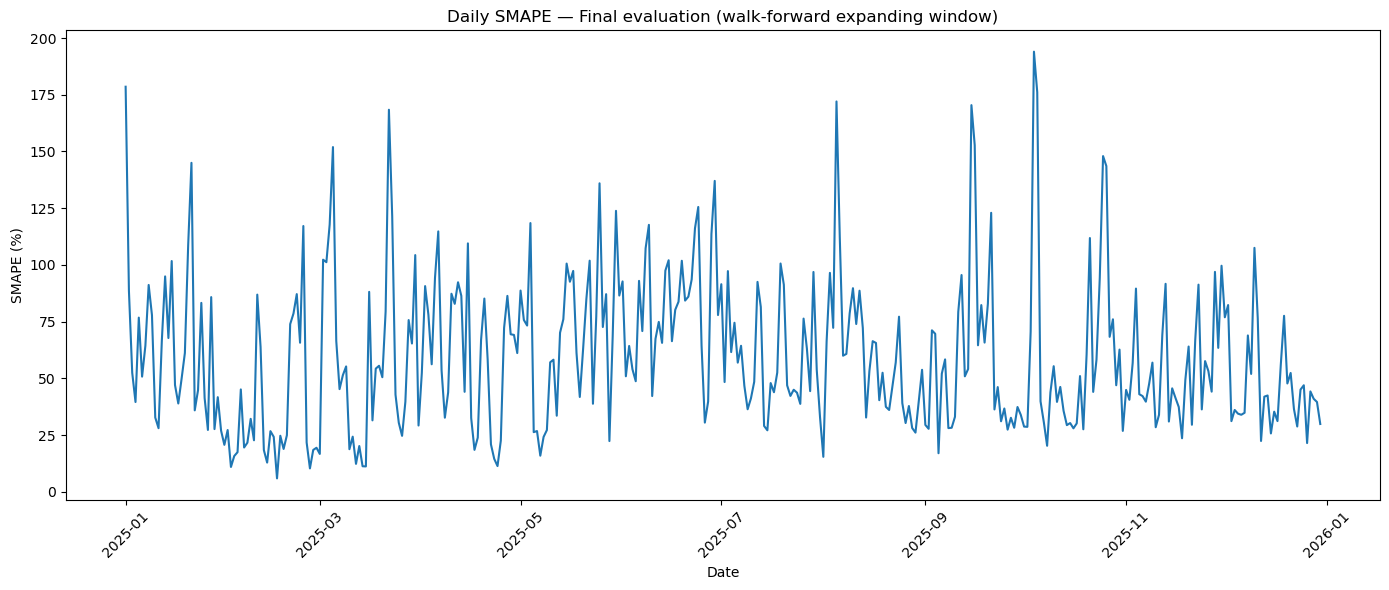

ValueError: If using all scalar values, you must pass an index

In [9]:
from Cross_Validation_runner_copy import run_final_evaluation
import itertools
import pandas as pd
import os

results = run_final_evaluation(
    model=model_DK2_actuals,  # your best model from hyperparameter search
    train_dataset=DK2_train,   # 9 years
    test_dataset=DK2_test,     # 1 year (from read_data.py, split at 2025-01-01)
    use_scaler=True,
    print_week_results=True,
    plot=True,
    one_step_ahead=False,      # set True to compare against oracle predictions
)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(python_dir, "Shallow learners")
folder = os.path.join(folder, "XGBoost")
base_filename = "DK2_final_evaluation_actuals_params.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_final_evaluation_actuals_params.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))